In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv(
    "C:/Users/Alan/Desktop/Trabalho_CESAR_ENEM_GO/dados/tratado/enem_escola_sample.csv"
)

disciplinas = [
    "Linguagens",
    "Matemática",
    "Ciências Humanas",
    "Ciências da Natureza",
    "Redação"
]

In [5]:
print(df["Tipo_Escola"].unique())

['Estadual' 'Privada' 'Federal' 'Municipal']


In [6]:
df["Tipo_Escola_Agrupado"] = df["Tipo_Escola"].replace({
    "Federal": "Pública",
    "Estadual": "Pública",
    "Municipal": "Pública",
    "Privada": "Privada"
})

In [9]:
go = df_go.groupby("Tipo_Escola_Agrupado")[disciplinas].mean()
br = df_br.groupby("Tipo_Escola_Agrupado")[disciplinas].mean()

In [10]:
publica_go = go.loc["Pública"]
privada_go = go.loc["Privada"]

['Pública' 'Privada']
['Pública' 'Privada']
Index(['Privada', 'Pública'], dtype='object', name='Tipo_Escola_Agrupado')
Index(['Privada', 'Pública'], dtype='object', name='Tipo_Escola_Agrupado')


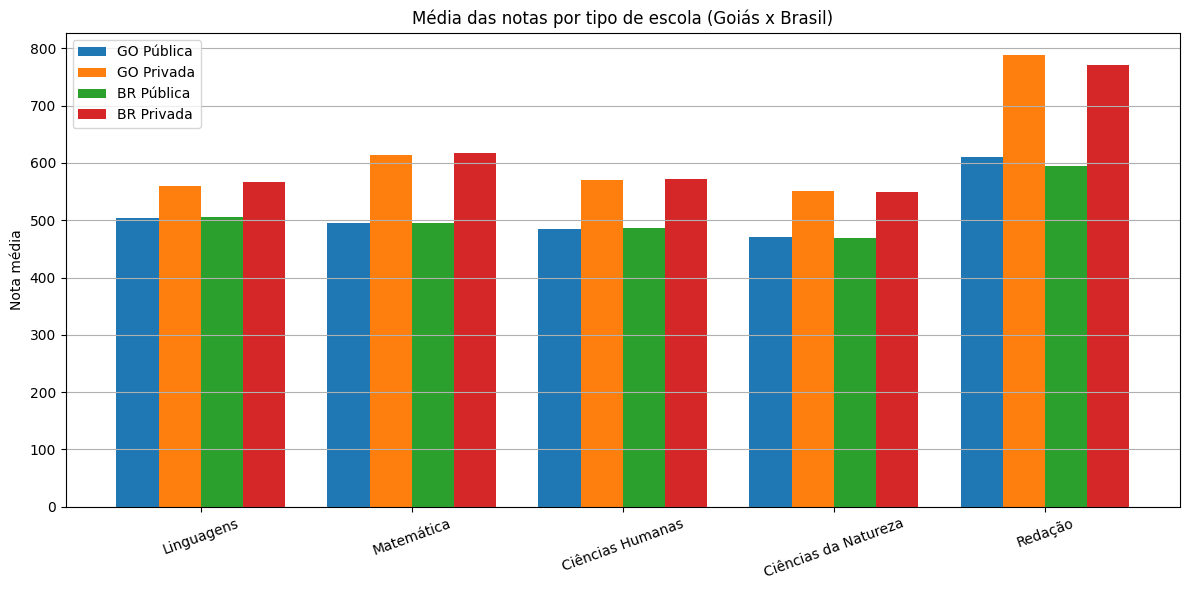

In [12]:
import matplotlib.pyplot as plt

disciplinas = [
    "Linguagens",
    "Matemática",
    "Ciências Humanas",
    "Ciências da Natureza",
    "Redação"
]

# separar GO e BR
df_go = df[df["SG_UF_PROVA"] == "GO"].copy()
df_br = df.copy()

# agrupar tipos de escola
mapa_escola = {
    "Federal": "Pública",
    "Estadual": "Pública",
    "Municipal": "Pública",
    "Privada": "Privada"
}

df_go["Tipo_Escola_Agrupado"] = df_go["Tipo_Escola"].replace(mapa_escola)
df_br["Tipo_Escola_Agrupado"] = df_br["Tipo_Escola"].replace(mapa_escola)

# conferir
print(df_go["Tipo_Escola_Agrupado"].unique())
print(df_br["Tipo_Escola_Agrupado"].unique())

# groupby na coluna AGRUPADA
go = df_go.groupby("Tipo_Escola_Agrupado")[disciplinas].mean()
br = df_br.groupby("Tipo_Escola_Agrupado")[disciplinas].mean()

# conferir índice
print(go.index)
print(br.index)

# preparar dados
publica_go = go.loc["Pública"]
privada_go = go.loc["Privada"]

publica_br = br.loc["Pública"]
privada_br = br.loc["Privada"]

x = range(len(disciplinas))

plt.figure(figsize=(12, 6))

plt.bar([i - 0.3 for i in x], publica_go, width=0.2, label="GO Pública")
plt.bar([i - 0.1 for i in x], privada_go, width=0.2, label="GO Privada")
plt.bar([i + 0.1 for i in x], publica_br, width=0.2, label="BR Pública")
plt.bar([i + 0.3 for i in x], privada_br, width=0.2, label="BR Privada")

plt.xticks(x, disciplinas, rotation=20)
plt.ylabel("Nota média")
plt.title("Média das notas por tipo de escola (Goiás x Brasil)")
plt.legend()
plt.grid(axis="y")
plt.tight_layout()

plt.savefig("grafico_escola_completo.png", dpi=300)
plt.show()